In [3]:
pip install faker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.2 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
from faker import Faker

fake = Faker()

num_students = 250

student_ids = [f'S{i:03d}' for i in range(1, num_students + 1)]
names = [fake.name() for _ in range(num_students)]
genders = np.random.choice(['Male', 'Female'], num_students)
departments = np.random.choice(['CSE', 'IT', 'ECE'], num_students)
years = np.random.choice(['1st', '2nd', '3rd'], num_students)
maths_marks = np.random.randint(40, 100, num_students)
science_marks = np.random.randint(40, 100, num_students)
english_marks = np.random.randint(40, 100, num_students)
attendance = np.random.randint(50, 101, num_students)
internal_marks = np.random.randint(0, 26, num_students)

students_data = pd.DataFrame({
    'Student_ID': student_ids,
    'Name': names,
    'Gender': genders,
    'Department': departments,
    'Year': years,
    'Maths': maths_marks,
    'Science': science_marks,
    'English': english_marks,
    'Attendance (%)': attendance,
    'Internal Marks': internal_marks
})

display(students_data)

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance (%),Internal Marks
0,S001,Nicholas Reeves,Female,CSE,1st,99,45,60,65,6
1,S002,Kevin Ward,Female,CSE,3rd,91,81,80,67,3
2,S003,Kimberly Butler,Female,ECE,1st,51,98,78,89,0
3,S004,Emily Shields,Female,ECE,2nd,73,77,83,89,22
4,S005,Mrs. Natalie Lowe,Female,IT,2nd,76,94,53,77,16
...,...,...,...,...,...,...,...,...,...,...
245,S246,Krystal Bryant,Female,IT,1st,75,93,86,57,11
246,S247,Brittany Hart,Male,IT,3rd,42,51,97,50,9
247,S248,Richard Stokes,Male,CSE,3rd,63,82,58,100,9
248,S249,Edward Graves,Male,IT,1st,85,48,69,89,15


In [5]:
students_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Student_ID      250 non-null    object
 1   Name            250 non-null    object
 2   Gender          250 non-null    object
 3   Department      250 non-null    object
 4   Year            250 non-null    object
 5   Maths           250 non-null    int64 
 6   Science         250 non-null    int64 
 7   English         250 non-null    int64 
 8   Attendance (%)  250 non-null    int64 
 9   Internal Marks  250 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 19.7+ KB


In [6]:
students_data.isnull().sum()


,0
Student_ID,0
Name,0
Gender,0
Department,0
Year,0
Maths,0
Science,0
English,0
Attendance (%),0
Internal Marks,0


Descriptive Statistics for Numerical Columns:
            Maths     Science     English  Attendance (%)  Internal Marks
count  250.000000  250.000000  250.000000       250.00000      250.000000
mean    70.508000   69.960000   69.780000        74.12000       12.400000
std     17.695152   16.906024   16.967356        14.87274        7.840273
min     40.000000   40.000000   40.000000        50.00000        0.000000
25%     55.000000   55.000000   55.000000        61.25000        6.000000
50%     71.000000   70.000000   70.500000        72.00000       12.000000
75%     85.750000   85.000000   83.000000        87.75000       19.000000
max     99.000000   99.000000   99.000000       100.00000       25.000000


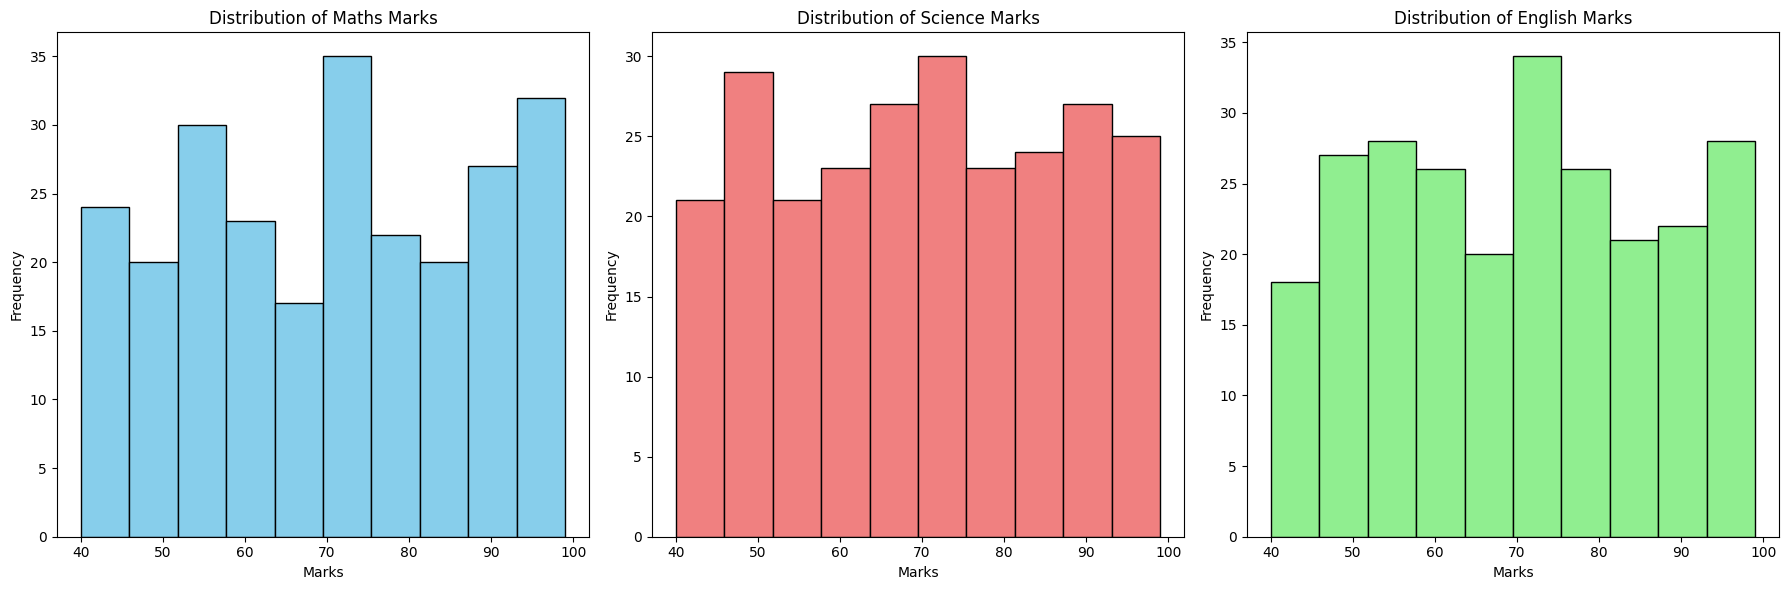

In [7]:
import matplotlib.pyplot as plt

# 1. Calculate and display descriptive statistics for numerical columns
numerical_columns = ['Maths', 'Science', 'English', 'Attendance (%)', 'Internal Marks']
descriptive_stats = students_data[numerical_columns].describe()
print("Descriptive Statistics for Numerical Columns:")
print(descriptive_stats)

# 2. Generate and display histograms for 'Maths', 'Science', and 'English'
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(students_data['Maths'], bins=10, edgecolor='black', color='skyblue')
plt.xlabel('Marks')
plt.ylabel('Frequency')
plt.title('Distribution of Maths Marks')

plt.subplot(1, 3, 2)
plt.hist(students_data['Science'], bins=10, edgecolor='black', color='lightcoral')
plt.xlabel('Marks')
plt.ylabel('Frequency')
plt.title('Distribution of Science Marks')

plt.subplot(1, 3, 3)
plt.hist(students_data['English'], bins=10, edgecolor='black', color='lightgreen')
plt.xlabel('Marks')
plt.ylabel('Frequency')
plt.title('Distribution of English Marks')

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

# 1. Calculate 'Total Marks'
students_data['Total Marks'] = students_data['Maths'] + students_data['Science'] + students_data['English']

# 2. Calculate 'Average Marks'
students_data['Average Marks'] = students_data['Total Marks'] / 3

# 3. Define the grading system function
def get_grade(average_marks):
    if average_marks >= 90:
        return 'A'
    elif average_marks >= 80:
        return 'B'
    elif average_marks >= 70:
        return 'C'
    elif average_marks >= 60:
        return 'D'
    else:
        return 'F'

# 4. Apply the grading system to create the 'Grade' column
students_data['Grade'] = students_data['Average Marks'].apply(get_grade)

# 5. Display the first few rows of the updated DataFrame
display(students_data.head())

,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance (%),Internal Marks,Total Marks,Average Marks,Grade
0,S001,Nicholas Reeves,Female,CSE,1st,99,45,60,65,6,204,68.000000,D
1,S002,Kevin Ward,Female,CSE,3rd,91,81,80,67,3,252,84.000000,B
2,S003,Kimberly Butler,Female,ECE,1st,51,98,78,89,0,227,75.666667,C
3,S004,Emily Shields,Female,ECE,2nd,73,77,83,89,22,233,77.666667,C
4,S005,Mrs. Natalie Lowe,Female,IT,2nd,76,94,53,77,16,223,74.333333,C


In [9]:
print("Top 10 Performing Students (based on Total Marks):")
top_10_students = students_data.sort_values(by='Total Marks', ascending=False).head(10)
display(top_10_students)

print("\nStudents with 'F' Grade (Low Performers):")
low_performing_students = students_data[students_data['Grade'] == 'F']
display(low_performing_students)

Top 10 Performing Students (based on Total Marks):


,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance (%),Internal Marks,Total Marks,Average Marks,Grade
181,S182,Gregory Page,Female,ECE,3rd,99,97,88,58,3,284,94.666667,A
131,S132,Amanda Fleming,Male,ECE,2nd,99,96,79,67,11,274,91.333333,A
18,S019,Robert Campbell,Female,CSE,1st,90,87,92,89,24,269,89.666667,B
218,S219,Victoria Horn,Female,CSE,3rd,90,79,99,62,6,268,89.333333,B
12,S013,Danielle Perez,Male,CSE,1st,80,89,97,90,16,266,88.666667,B
190,S191,Marcus Jimenez,Female,ECE,1st,90,76,99,97,10,265,88.333333,B
162,S163,Dustin Robinson,Female,ECE,2nd,95,88,81,97,3,264,88.000000,B
29,S030,Caitlin Farley,Female,IT,2nd,66,98,98,58,5,262,87.333333,B
178,S179,Jacob Stuart,Male,CSE,2nd,78,85,98,51,4,261,87.000000,B
5,S006,Breanna Alexander,Male,ECE,1st,78,85,97,71,19,260,86.666667,B



Students with 'F' Grade (Low Performers):


,Student_ID,Name,Gender,Department,Year,Maths,Science,English,Attendance (%),Internal Marks,Total Marks,Average Marks,Grade
6,S007,Catherine Molina,Male,IT,1st,52,51,46,98,2,149,49.666667,F
11,S012,Sarah West,Male,ECE,1st,52,53,50,52,3,155,51.666667,F
21,S022,Rebecca Vega,Female,ECE,1st,71,49,58,82,14,178,59.333333,F
26,S027,Richard Haynes DDS,Male,ECE,2nd,48,73,46,71,11,167,55.666667,F
37,S038,Mrs. Jessica Johnston,Female,IT,3rd,77,41,61,69,24,179,59.666667,F
40,S041,Kevin Serrano,Female,IT,3rd,50,66,48,70,21,164,54.666667,F
45,S046,Frederick Clark,Male,ECE,2nd,76,44,48,64,17,168,56.000000,F
52,S053,Jacob Martin,Female,CSE,1st,42,70,50,72,8,162,54.000000,F
61,S062,Gene Hale,Female,ECE,2nd,59,54,66,82,13,179,59.666667,F
68,S069,Patricia Holloway,Male,IT,3rd,63,51,58,81,17,172,57.333333,F



Average Total Marks by Department:
Department
CSE    211.435294
ECE    212.989130
IT     205.410959
Name: Total Marks, dtype: float64

Average Total Marks by Gender:
Gender
Female    212.598485
Male      207.618644
Name: Total Marks, dtype: float64

Average Total Marks by Year:
Year
1st    211.988506
2nd    210.300000
3rd    208.373494
Name: Total Marks, dtype: float64


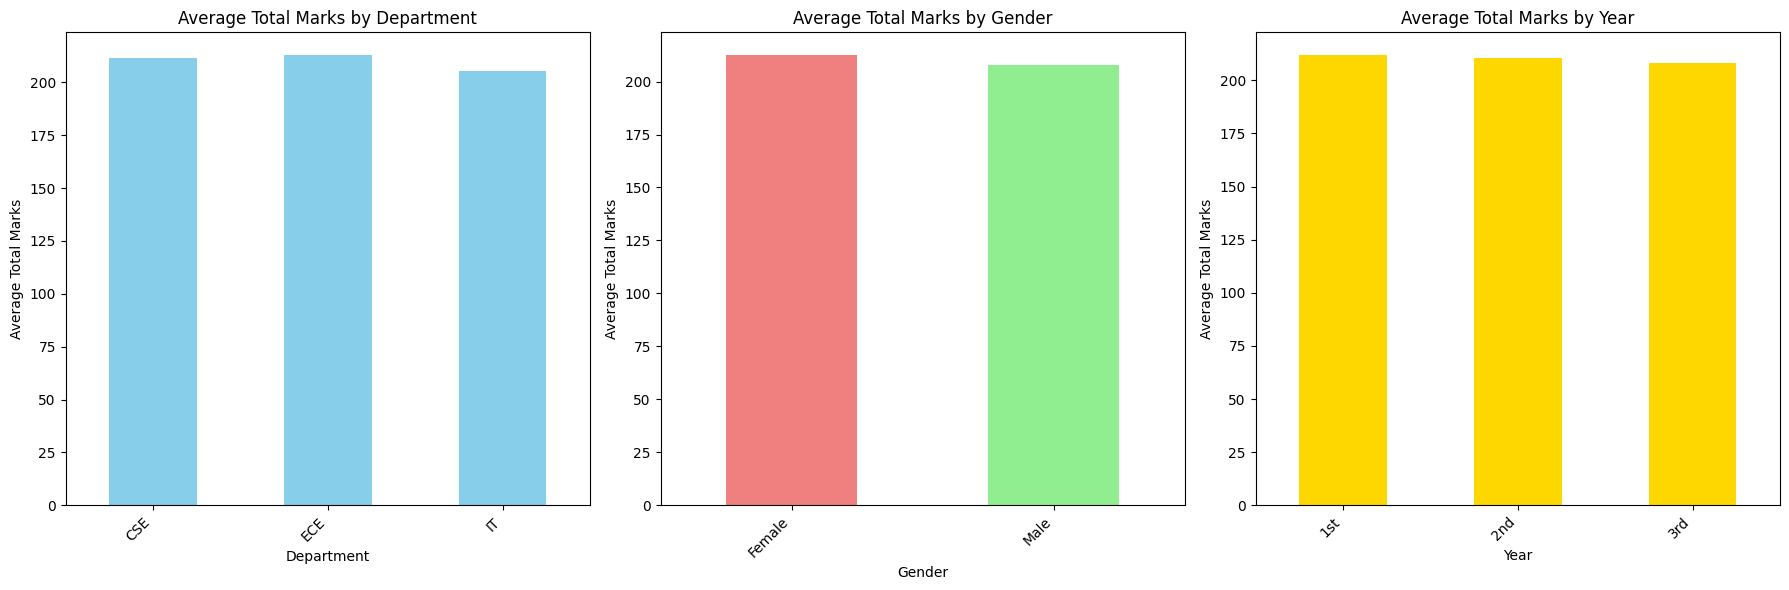

In [10]:
import matplotlib.pyplot as plt

# 1. Calculate average 'Total Marks' by 'Department'
department_performance = students_data.groupby('Department')['Total Marks'].mean()
print("\nAverage Total Marks by Department:")
print(department_performance)

# 2. Calculate average 'Total Marks' by 'Gender'
gender_performance = students_data.groupby('Gender')['Total Marks'].mean()
print("\nAverage Total Marks by Gender:")
print(gender_performance)

# 3. Calculate average 'Total Marks' by 'Year'
year_performance = students_data.groupby('Year')['Total Marks'].mean()
print("\nAverage Total Marks by Year:")
print(year_performance)

# Visualize the analyses using bar charts
plt.figure(figsize=(18, 6))

# Bar chart for Department-wise performance
plt.subplot(1, 3, 1)
department_performance.plot(kind='bar', color='skyblue')
plt.xlabel('Department')
plt.ylabel('Average Total Marks')
plt.title('Average Total Marks by Department')
plt.xticks(rotation=45, ha='right')

# Bar chart for Gender-wise performance
plt.subplot(1, 3, 2)
gender_performance.plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.xlabel('Gender')
plt.ylabel('Average Total Marks')
plt.title('Average Total Marks by Gender')
plt.xticks(rotation=45, ha='right')

# Bar chart for Year-wise performance
plt.subplot(1, 3, 3)
year_performance.plot(kind='bar', color='gold')
plt.xlabel('Year')
plt.ylabel('Average Total Marks')
plt.title('Average Total Marks by Year')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

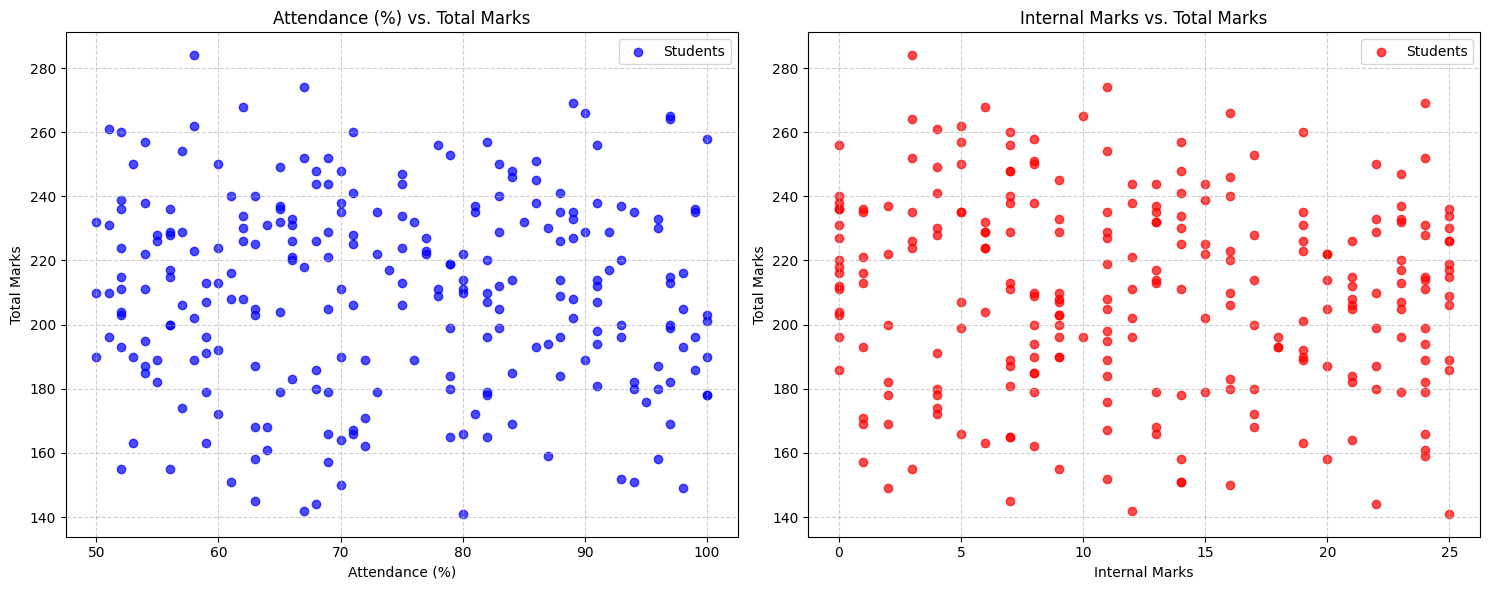


Pearson Correlation between Attendance (%) and Total Marks: -0.04
Pearson Correlation between Internal Marks and Total Marks: -0.09


In [11]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# Scatter plot for 'Attendance (%)' vs 'Total Marks'
plt.subplot(1, 2, 1)
plt.scatter(students_data['Attendance (%)'], students_data['Total Marks'], color='blue', alpha=0.7, label='Students')
plt.xlabel('Attendance (%)')
plt.ylabel('Total Marks')
plt.title('Attendance (%) vs. Total Marks')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Scatter plot for 'Internal Marks' vs 'Total Marks'
plt.subplot(1, 2, 2)
plt.scatter(students_data['Internal Marks'], students_data['Total Marks'], color='red', alpha=0.7, label='Students')
plt.xlabel('Internal Marks')
plt.ylabel('Total Marks')
plt.title('Internal Marks vs. Total Marks')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Calculate and print correlation coefficients
correlation_attendance_total = students_data['Attendance (%)'].corr(students_data['Total Marks'])
print(f"\nPearson Correlation between Attendance (%) and Total Marks: {correlation_attendance_total:.2f}")

correlation_internal_total = students_data['Internal Marks'].corr(students_data['Total Marks'])
print(f"Pearson Correlation between Internal Marks and Total Marks: {correlation_internal_total:.2f}")

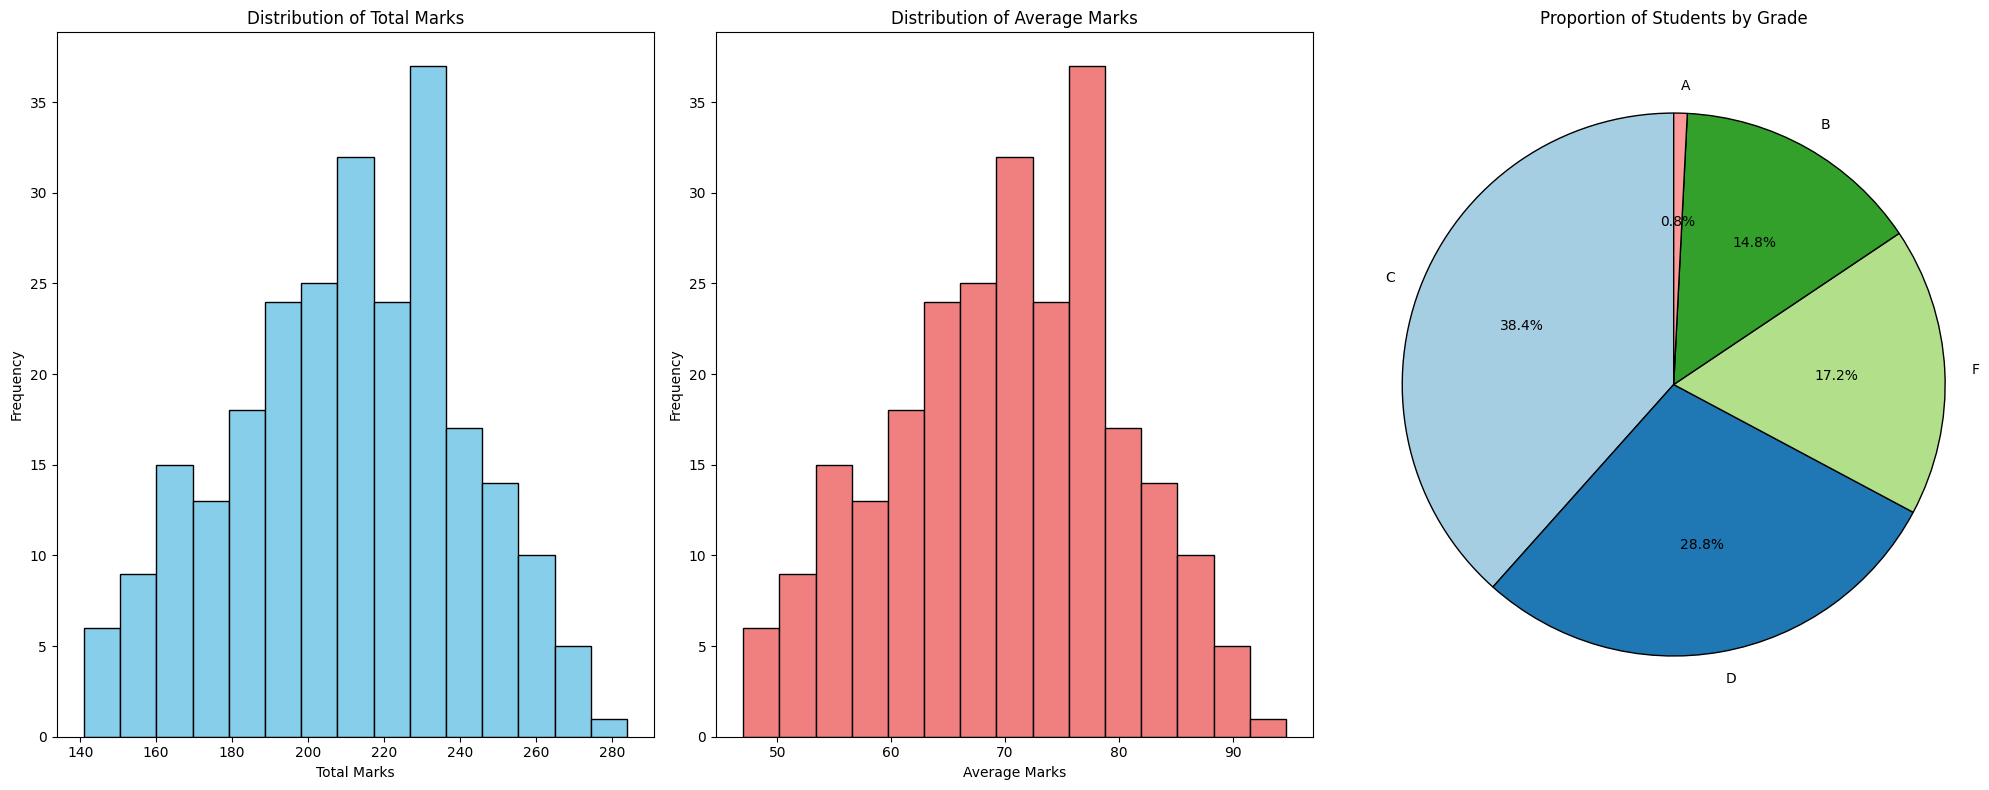

In [12]:
import matplotlib.pyplot as plt

# 1. Create a figure to display multiple plots
plt.figure(figsize=(20, 8))

# 2. Histogram for 'Total Marks'
plt.subplot(1, 3, 1) # 1 row, 3 columns, first plot
plt.hist(students_data['Total Marks'], bins=15, edgecolor='black', color='skyblue')
plt.xlabel('Total Marks')
plt.ylabel('Frequency')
plt.title('Distribution of Total Marks')

# 3. Histogram for 'Average Marks'
plt.subplot(1, 3, 2) # 1 row, 3 columns, second plot
plt.hist(students_data['Average Marks'], bins=15, edgecolor='black', color='lightcoral')
plt.xlabel('Average Marks')
plt.ylabel('Frequency')
plt.title('Distribution of Average Marks')

# 4. Calculate the counts of students for each unique 'Grade' category
grade_counts = students_data['Grade'].value_counts()

# 5. Create a pie chart for 'Grade' distribution
plt.subplot(1, 3, 3) # 1 row, 3 columns, third plot
plt.pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors, wedgeprops={'edgecolor': 'black'})
plt.title('Proportion of Students by Grade')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

# 6. Display all generated plots
plt.tight_layout()
plt.show()